In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
print(data.data.shape)
print(data.target.shape)

(569, 30)
(569,)


In [4]:
## Create X and y
X = data.data
y = data.target
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [5]:
print(data.target_names)

['malignant' 'benign']


In [6]:
## Understand the target variable
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [7]:
import numpy as np
print(np.bincount(y))

[212 357]


In [10]:
print(np.bincount(y) / len(y)*100)

[37.25834798 62.74165202]


The dataset is balanced because no data below 30%

In [12]:
## Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [13]:
## Standardize the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
## Check the standardized data
print(X_train_scaled[:5])

[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1.73738602e-01]
 [-9.7

## Create the Logistic Regression model

In [15]:
## Create the Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

# training is happening here
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [16]:
# Check whether the model trained successfully
print(model.coef_)
print(model.intercept_)

[[-0.51147901 -0.55269775 -0.47629789 -0.54105924 -0.21247927  0.64834159
  -0.60210291 -0.70415649 -0.16723273  0.19973173 -1.08296534  0.24882301
  -0.54433323 -0.92910402 -0.16027571  0.64722656  0.16056252 -0.44378424
   0.36049156  0.43789426 -0.94761615 -1.25508804 -0.76322007 -0.9477559
  -0.74662481  0.05551412 -0.82315065 -0.95368636 -0.93918141 -0.1872508 ]]
[0.30220757]


In [17]:
## Make predictions
y_pred = model.predict(X_test_scaled)
print(y_pred)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [18]:
## compare predictions and actual values
print("Actual:   ", y_test[:10])
print("Predicted:", y_pred[:10])

Actual:    [0 1 0 1 0 1 1 0 0 0]
Predicted: [0 1 0 1 0 1 1 0 0 0]


In [19]:
## Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


In [20]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41  1]
 [ 1 71]]


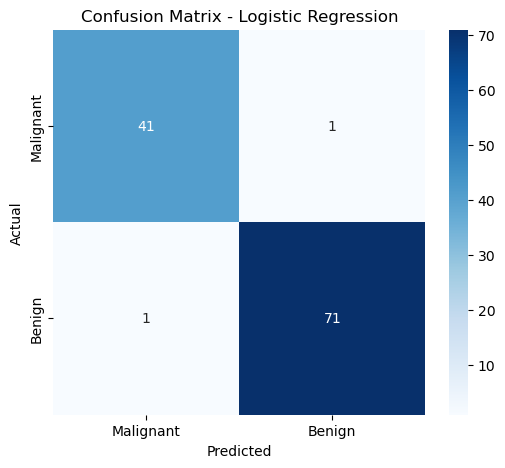

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [22]:
## Generate the classification report - Precision, Recall, and F1-score
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [25]:
## Probabilities
import numpy as np
np.set_printoptions(suppress=True, precision=10)
y_prob = model.predict_proba(X_test_scaled)
print(y_prob[:5])

[[0.9999999411 0.0000000589]
 [0.0000113352 0.9999886648]
 [0.9935891754 0.0064108246]
 [0.466491463  0.533508537 ]
 [0.9999999993 0.0000000007]]


In [26]:
## Extract the probability of malignant
malignant_prob = y_prob[:, 0]

print(malignant_prob[:10])

[0.9999999411 0.0000113352 0.9935891754 0.466491463  0.9999999993
 0.0078396016 0.0000171747 0.9999994365 0.9999456836 0.9999999999]


In [27]:
##
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Malignant_Probability": y_prob[:, 0],
    "Benign_Probability": y_prob[:, 1]
})

print(results.head(10))

   Actual  Predicted  Malignant_Probability  Benign_Probability
0       0          0               1.000000        5.888242e-08
1       1          1               0.000011        9.999887e-01
2       0          0               0.993589        6.410825e-03
3       1          1               0.466491        5.335085e-01
4       0          0               1.000000        6.525001e-10
5       1          1               0.007840        9.921604e-01
6       1          1               0.000017        9.999828e-01
7       0          0               0.999999        5.635275e-07
8       0          0               0.999946        5.431637e-05
9       0          0               1.000000        8.041849e-11


In [29]:
## FEATURE IMPORATANCE
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance)

                    Feature  Coefficient
5          mean compactness     0.648342
15        compactness error     0.647227
19  fractal dimension error     0.437894
18           symmetry error     0.360492
11            texture error     0.248823
9    mean fractal dimension     0.199732
16          concavity error     0.160563
25        worst compactness     0.055514
14         smoothness error    -0.160276
8             mean symmetry    -0.167233
29  worst fractal dimension    -0.187251
4           mean smoothness    -0.212479
17     concave points error    -0.443784
2            mean perimeter    -0.476298
0               mean radius    -0.511479
3                 mean area    -0.541059
12          perimeter error    -0.544333
1              mean texture    -0.552698
6            mean concavity    -0.602103
7       mean concave points    -0.704156
24         worst smoothness    -0.746625
22          worst perimeter    -0.763220
26          worst concavity    -0.823151
13              

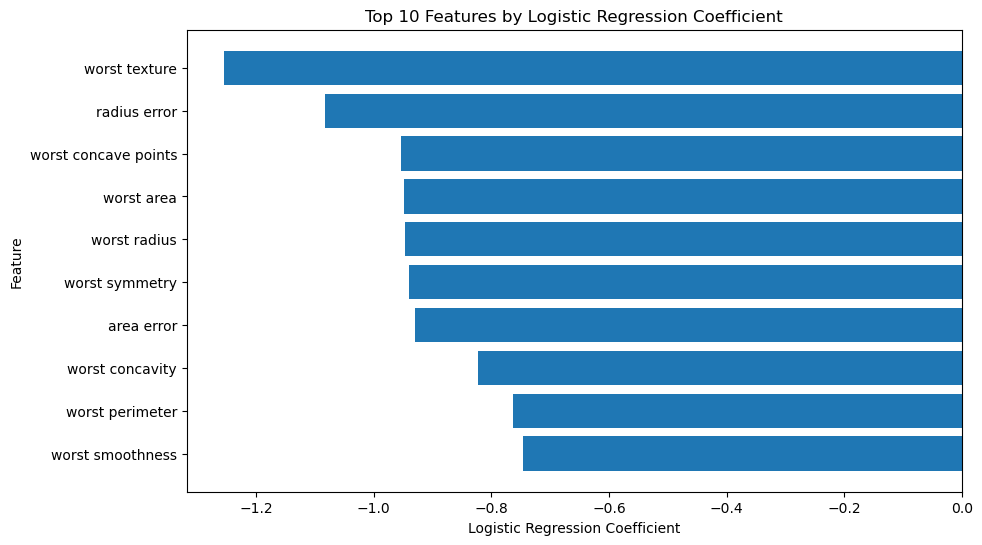

In [30]:
###
import matplotlib.pyplot as plt
import pandas as pd

# Get coefficients
coefficients = model.coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Coefficient": coefficients
})

# Calculate absolute coefficient
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Select top 10
top_features = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features by Logistic Regression Coefficient")

plt.gca().invert_yaxis()

plt.show()

The Logistic Regression model achieved an accuracy of 98.25% on the test dataset.
It demonstrated strong performance for both malignant and benign cases, with F1-scores of 0.98 and 0.99, respectively.
The model correctly classified 41 of 42 malignant cases, missing only one malignant case.
The confusion matrix shows only two misclassifications out of 114 test observations.
Overall, the model performed very well and shows strong potential for classifying breast cancer cases in this dataset.

In [31]:
## MODEL EQUATION
print("Intercept:", model.intercept_[0])

for feature, coef in zip(data.feature_names, model.coef_[0]):
    print(f"{feature}: {coef:.6f}")

Intercept: 0.3022075735370282
mean radius: -0.511479
mean texture: -0.552698
mean perimeter: -0.476298
mean area: -0.541059
mean smoothness: -0.212479
mean compactness: 0.648342
mean concavity: -0.602103
mean concave points: -0.704156
mean symmetry: -0.167233
mean fractal dimension: 0.199732
radius error: -1.082965
texture error: 0.248823
perimeter error: -0.544333
area error: -0.929104
smoothness error: -0.160276
compactness error: 0.647227
concavity error: 0.160563
concave points error: -0.443784
symmetry error: 0.360492
fractal dimension error: 0.437894
worst radius: -0.947616
worst texture: -1.255088
worst perimeter: -0.763220
worst area: -0.947756
worst smoothness: -0.746625
worst compactness: 0.055514
worst concavity: -0.823151
worst concave points: -0.953686
worst symmetry: -0.939181
worst fractal dimension: -0.187251
